# 표정 분류 CNN — 학습 이력 분석 및 이모지 변환 수정

**원본**: 2023년 인공지능 과제 (`Emoji_Autoencoder.ipynb`, Colab)
**작성**: 2026-09-10

이 노트북은 **모델을 다시 학습시키지 않는다.** 그럴 수 없기 때문이다 —
원본 노트북에 `model.save()` 호출이 없어서 **학습된 가중치가 Colab 세션과 함께 사라졌고**,
데이터셋(Kaggle 24,400장)도 로컬에 없다.

대신 남아 있는 것으로 할 수 있는 두 가지를 한다.

| # | 하는 일 | 근거 자료 |
|---|---|---|
| 1 | **20에폭 학습 로그를 정량 분석** — "에폭이 부족했다"는 기존 결론이 맞는지 검증 | 원본 노트북에 남은 출력 텍스트 |
| 2 | **이모지 변환 버그를 실제로 수정하고 실행** — 흰 이미지만 나오던 문제 | `emoji_df.csv` + PIL |

두 작업 모두 이 노트북에서 실제로 실행되며, 출력은 전부 실행 결과다.
원본 노트북은 그대로 보존한다.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, re, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

plt.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('준비 완료')

준비 완료


## 1. 학습 이력 복원

원본 노트북의 학습 셀 출력에 20에폭 로그가 그대로 남아 있다. 파싱해서 표로 만든다.

In [2]:
nb_src = json.load(open('Emoji_Autoencoder.ipynb', encoding='utf-8'))
log = ''.join(''.join(o.get('text', [])) for o in nb_src['cells'][3].get('outputs', []))

rows = re.findall(r'loss: ([\d.]+) - accuracy: ([\d.]+) - val_loss: ([\d.]+) - val_accuracy: ([\d.]+)', log)
hist = pd.DataFrame(rows, columns=['train_loss', 'train_acc', 'val_loss', 'val_acc']).astype(float)
hist.index = range(1, len(hist) + 1); hist.index.name = 'epoch'

secs = [int(x) for x in re.findall(r'\] - (\d+)s ', log)]
print(f'파싱된 에폭: {len(hist)}개 (출력 잘림 없음)')
print(f'총 학습 시간: {sum(secs)}초 = {sum(secs)/60:.1f}분  (에폭당 평균 {sum(secs)/len(secs):.1f}초)')
print()
print(hist.round(4).to_string())

파싱된 에폭: 20개 (출력 잘림 없음)
총 학습 시간: 1076초 = 17.9분  (에폭당 평균 53.8초)

       train_loss  train_acc  val_loss  val_acc
epoch                                          
1          1.7510     0.2869    1.6069   0.3876
2          1.5865     0.3820    1.4736   0.4288
3          1.4900     0.4235    1.4715   0.4392
4          1.4217     0.4537    1.3422   0.4791
5          1.3810     0.4714    1.3053   0.5042
6          1.3373     0.4879    1.2825   0.5168
7          1.3190     0.4993    1.2676   0.5133
8          1.2925     0.5103    1.2880   0.5112
9          1.2701     0.5184    1.2713   0.5140
10         1.2562     0.5265    1.2292   0.5321
11         1.2389     0.5286    1.1931   0.5307
12         1.2189     0.5377    1.2130   0.5258
13         1.2112     0.5408    1.1888   0.5419
14         1.1972     0.5469    1.1994   0.5412
15         1.1848     0.5522    1.1832   0.5412
16         1.1791     0.5526    1.1857   0.5489
17         1.1740     0.5599    1.1738   0.5656
18         1.1604     0.5

20에폭이 온전히 남아 있다. 이 숫자들이 아래 분석의 유일한 근거다.

## 2. 기본 지표 확인

In [3]:
last = hist.iloc[-1]
print(f"최종 검증 정확도 : {last.val_acc:.4f}")
print(f"최고 검증 정확도 : {hist.val_acc.max():.4f} (에폭 {hist.val_acc.idxmax()})")
print(f"최종 훈련 정확도 : {last.train_acc:.4f}")
print(f"무작위 기준선     : {1/7:.4f}  (7클래스)")
print(f"기준선 대비       : {last.val_acc/(1/7):.2f}배")
print(f"\n최종 훈련-검증 격차: {last.train_acc - last.val_acc:+.4f}   → 과적합 거의 없음")
print(f"val_loss 최저값   : {hist.val_loss.min():.4f} (에폭 {hist.val_loss.idxmin()})")

최종 검증 정확도 : 0.5628
최고 검증 정확도 : 0.5656 (에폭 17)
최종 훈련 정확도 : 0.5705
무작위 기준선     : 0.1429  (7클래스)
기준선 대비       : 3.94배

최종 훈련-검증 격차: +0.0077   → 과적합 거의 없음
val_loss 최저값   : 1.1655 (에폭 20)


정확도 0.5628은 무작위(0.1429)의 **3.9배**이고, 훈련-검증 격차가 **+0.0077**로 과적합은 거의 없다.
`Dropout(0.5)`와 데이터 증강이 제 역할을 한 것으로 보인다.

여기까지는 기존 README와 같다. 문제는 다음 항목이다.

## 3. 검증 — "에폭이 부족했다"는 결론이 맞는가

기존 README는 이렇게 적었다.

> 검증 손실이 **마지막 20에폭에서 최저(1.1655)** 를 기록했다.
> 즉 조기 종료 지점에 도달한 것이 아니라 **에폭이 부족한 상태**이며, 더 학습하면 개선 여지가 있다.

이 서술은 **마지막 한 점만 보고 내린 판단**이다. 그 앞뒤를 함께 본다.

In [4]:
print('마지막 4에폭')
print(hist.loc[17:].round(4).to_string())
print(f"\nval_loss: {' → '.join(f'{v:.4f}' for v in hist.loc[17:, 'val_loss'])}")
print(f"val_acc : {' → '.join(f'{v:.4f}' for v in hist.loc[17:, 'val_acc'])}")

up = list(hist.val_loss.diff().dropna()[lambda s: s > 0].index)
print(f"\nval_loss가 상승한 에폭: {up}  ({len(up)}회) → 단조 감소가 아니다")

마지막 4에폭
       train_loss  train_acc  val_loss  val_acc
epoch                                          
17         1.1740     0.5599    1.1738   0.5656
18         1.1604     0.5585    1.2112   0.5419
19         1.1562     0.5614    1.2333   0.5272
20         1.1446     0.5705    1.1655   0.5628

val_loss: 1.1738 → 1.2112 → 1.2333 → 1.1655
val_acc : 0.5656 → 0.5419 → 0.5272 → 0.5628

val_loss가 상승한 에폭: [8, 12, 14, 16, 18, 19]  (6회) → 단조 감소가 아니다


20에폭의 val_loss 최저값은 **1.2112 → 1.2333으로 두 에폭 연속 오른 직후의 반등**이다.
전체적으로도 val_loss는 6개 에폭에서 상승했다 — 단조 감소 곡선이 아니라 **진동하는 곡선**이다.

게다가 **검증 정확도는 에폭 17에서 이미 최고(0.5656)를 찍고 그 뒤로 내려왔다.**
마지막 구간의 추세를 기울기로 확인한다.

In [5]:
seg = hist.loc[16:]
for col in ['val_acc', 'val_loss']:
    slope = np.polyfit(seg.index, seg[col], 1)[0]
    print(f'에폭 16~20 {col:9} 기울기: {slope:+.5f} / 에폭')

print('\n구간별 검증 정확도 개선 속도')
for a, b in [(1, 10), (11, 20)]:
    s = hist.loc[a:b, 'val_acc']
    print(f'  에폭 {a:2}~{b:2}: {s.iloc[0]:.4f} → {s.iloc[-1]:.4f}   {(s.iloc[-1]-s.iloc[0])/(b-a):+.5f} / 에폭')
r1 = (hist.loc[10,'val_acc']-hist.loc[1,'val_acc'])/9
r2 = (hist.loc[20,'val_acc']-hist.loc[11,'val_acc'])/9
print(f'\n후반 개선 속도는 전반의 {r2/r1*100:.0f}% 수준으로 떨어졌다')

에폭 16~20 val_acc   기울기: -0.00106 / 에폭
에폭 16~20 val_loss  기울기: +0.00191 / 에폭

구간별 검증 정확도 개선 속도
  에폭  1~10: 0.3876 → 0.5321   +0.01606 / 에폭
  에폭 11~20: 0.5307 → 0.5628   +0.00357 / 에폭

후반 개선 속도는 전반의 22% 수준으로 떨어졌다


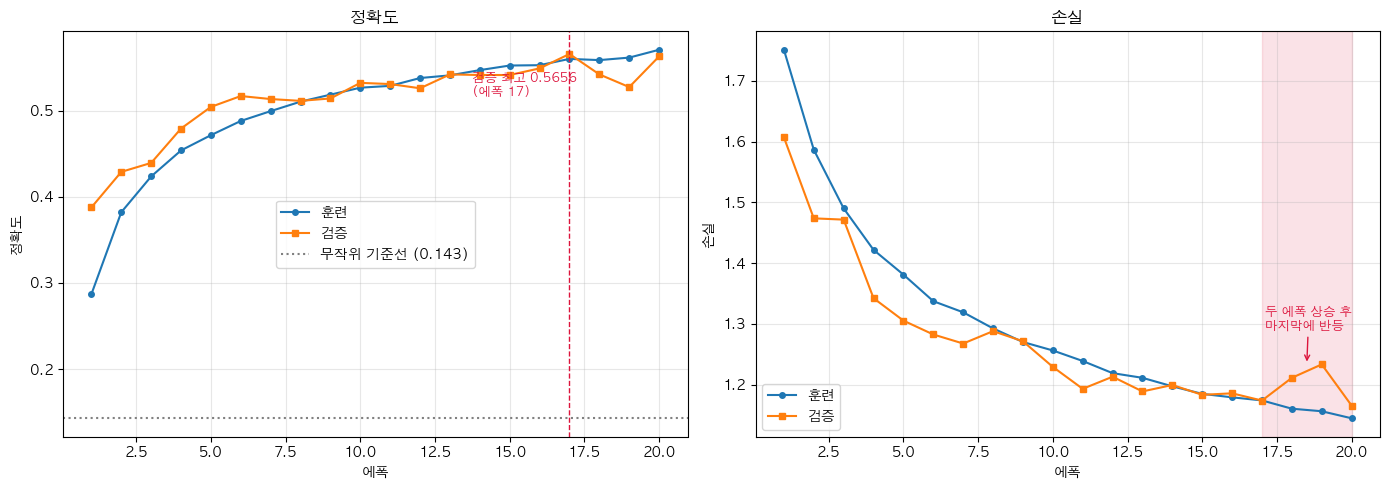

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(hist.index, hist.train_acc, 'o-', label='훈련', lw=1.5, ms=4)
ax.plot(hist.index, hist.val_acc, 's-', label='검증', lw=1.5, ms=4)
ax.axhline(1/7, ls=':', c='gray', label='무작위 기준선 (0.143)')
ax.axvline(hist.val_acc.idxmax(), ls='--', c='crimson', lw=1)
ax.annotate(f'검증 최고 {hist.val_acc.max():.4f}\n(에폭 {hist.val_acc.idxmax()})',
            (hist.val_acc.idxmax(), hist.val_acc.max()),
            textcoords='offset points', xytext=(-70, -30), color='crimson', fontsize=9)
ax.set_xlabel('에폭'); ax.set_ylabel('정확도'); ax.set_title('정확도'); ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
ax.plot(hist.index, hist.train_loss, 'o-', label='훈련', lw=1.5, ms=4)
ax.plot(hist.index, hist.val_loss, 's-', label='검증', lw=1.5, ms=4)
ax.axvspan(17, 20, alpha=.12, color='crimson')
ax.annotate('두 에폭 상승 후\n마지막에 반등', (18.5, hist.loc[19, 'val_loss']),
            textcoords='offset points', xytext=(-30, 25), color='crimson', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1))
ax.set_xlabel('에폭'); ax.set_ylabel('손실'); ax.set_title('손실'); ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

**결론 — 기존 서술을 정정한다.**

| | 기존 README | 재분석 |
|---|---|---|
| 근거 | val_loss가 20에폭에서 최저 | val_loss는 6회 상승한 **진동 곡선**, 20에폭 값은 2에폭 상승 뒤의 반등 |
| 검증 정확도 | (언급 없음) | **에폭 17에서 최고**를 찍고 하락 |
| 마지막 5에폭 추세 | (측정 안 함) | val_acc **−0.001/에폭**, val_loss **+0.002/에폭** |
| 개선 속도 | (측정 안 함) | 후반 10에폭은 전반의 **22%** 수준 |
| 판정 | "에폭이 부족하다, 더 학습하면 개선된다" | **이 데이터로는 지지되지 않는다.** 에폭 13~17에서 이미 0.54~0.57 대에 정체 |

**"더 학습하면 정확도가 오른다"는 결론은 로그로 뒷받침되지 않는다.**
모델은 이미 평탄 구간에 들어갔고, 마지막 val_loss 최저값은 진동 속의 한 점이다.

정확도를 올리려면 에폭을 늘리는 것이 아니라 **다른 것**을 바꿔야 한다 —
학습률 스케줄링, 더 깊은 구조, 배치 정규화 같은 것들이다. (이 노트북에서는 검증하지 못했다. `[미검증]`)

## 4. 이모지 변환 버그 수정

원본의 실패한 부분이다. 코드는 이랬다.

```python
for i, emoji in enumerate(selected_data):
    emoji_image = Image.new('RGB', (48, 48), color='white')   # 흰 배경 생성
    emoji_draw  = ImageDraw.Draw(emoji_image)                 # draw 객체 생성
    # ← draw.text() 호출이 없다
    emoji_image.save(f"{output_directory}/emoji_{i+1}.png")   # 흰 이미지 그대로 저장
```

`ImageDraw.Draw()` 객체를 만들기만 하고 **이모지를 그리는 호출이 없다.**
흰 이미지가 나오는 것이 당연한 결과였다. 원본을 그대로 재현해 확인한다.

In [7]:
emoji_df = pd.read_csv('emoji_df.csv')
selected_data = emoji_df.iloc[0:105, 0]          # 원본과 동일한 선택
print(f'대상 이모지 {len(selected_data)}개 — {"".join(selected_data[:10])} ...')

# --- 원본 코드 재현 ---
img = Image.new('RGB', (48, 48), color='white')
draw = ImageDraw.Draw(img)                        # 만들기만 하고 사용하지 않음
lo, hi = img.convert('L').getextrema()
print(f'\n원본 방식 결과 — 픽셀 최소/최대: {lo}/{hi}  → {"전부 흰색 (재현됨)" if lo == 255 else "무언가 그려짐"}')

대상 이모지 105개 — 😀😃😄😁😆😅🤣😂🙂🙃 ...

원본 방식 결과 — 픽셀 최소/최대: 255/255  → 전부 흰색 (재현됨)


흰 이미지가 그대로 재현된다. 이제 빠진 호출을 넣는다.

두 가지를 원본과 다르게 한다.

1. **컬러 이모지 폰트를 지정**한다 (`Apple Color Emoji.ttc`). 기본 폰트로는 이모지 글리프가 없다.
2. **160px로 렌더링한 뒤 48px로 축소**한다. Apple Color Emoji는 비트맵 기반이라
   임의 크기를 받지 않는다(48·96·160만 허용, 137은 `invalid pixel size` 오류).
   큰 크기로 그린 뒤 `LANCZOS`로 줄이는 쪽이 결과가 깨끗하다.

In [8]:
FONT_PATH = '/System/Library/Fonts/Apple Color Emoji.ttc'
RENDER, TARGET = 160, 48
font = ImageFont.truetype(FONT_PATH, RENDER)

def emoji_to_image(ch, render=RENDER, target=TARGET):
    """이모지 문자 하나를 target×target 이미지로 변환한다."""
    im = Image.new('RGB', (render, render), 'white')
    d = ImageDraw.Draw(im)
    bbox = d.textbbox((0, 0), ch, font=font, embedded_color=True)   # 글리프 위치 보정
    d.text((-bbox[0], -bbox[1]), ch, font=font, embedded_color=True)  # ← 빠져 있던 호출
    return im.resize((target, target), Image.LANCZOS)

out_dir = 'emoji_images_fixed'
os.makedirs(out_dir, exist_ok=True)

drawn = blank = 0
for i, ch in enumerate(selected_data):
    im = emoji_to_image(ch)
    if im.convert('L').getextrema()[0] == 255: blank += 1
    else: drawn += 1
    im.save(f'{out_dir}/emoji_{i+1}.png')

print(f'{len(selected_data)}개 중 실제로 그려진 것: {drawn}개,  흰 이미지: {blank}개')
print(f'저장 위치: {out_dir}/')

105개 중 실제로 그려진 것: 105개,  흰 이미지: 0개
저장 위치: emoji_images_fixed/


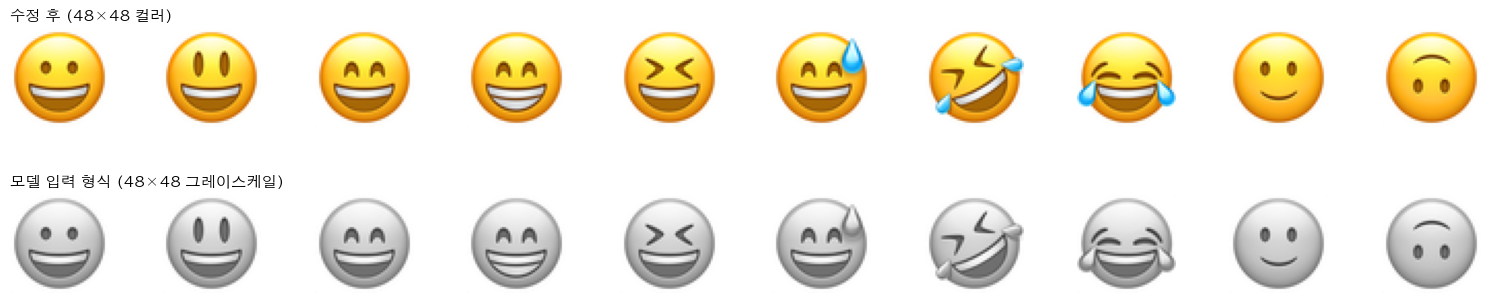

In [9]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.6))
for ax, ch in zip(axes[0], selected_data[:10]):
    ax.imshow(emoji_to_image(ch)); ax.axis('off')
axes[0][0].set_title('수정 후 (48×48 컬러)', loc='left', fontsize=11)

for ax, ch in zip(axes[1], selected_data[:10]):
    ax.imshow(emoji_to_image(ch).convert('L'), cmap='gray', vmin=0, vmax=255); ax.axis('off')
axes[1][0].set_title('모델 입력 형식 (48×48 그레이스케일)', loc='left', fontsize=11)

plt.tight_layout(); plt.show()

**105개 전부 정상 변환된다.** 3년 전 실패했던 단계가 `draw.text()` 한 줄과 폰트 지정으로 해결됐다.

## 5. 그런데 — 이 실험은 애초에 성립했는가

버그를 고쳤으니 다음 단계는 이 이모지들을 모델에 넣어보는 것이다. **하지 못한다. 두 가지 이유로.**

**첫째, 가중치가 없다.** 원본 노트북에 `model.save()` 호출이 없어 학습된 모델은 Colab 세션과 함께 사라졌다.
재학습하려면 Kaggle 데이터셋 24,400장과 TensorFlow 환경이 필요하다.

**둘째, 더 근본적으로 — 가중치가 있어도 결과에 의미가 없다.**

위 그림의 아래 줄이 모델이 실제로 받게 될 입력이다. 모델이 학습한 것과 비교해보자.

In [10]:
comparison = pd.DataFrame({
    '학습 데이터 (FER)': ['사람 얼굴 사진', '48×48 그레이스케일', '자연광·다양한 각도/조명',
                          '연속적인 명암 계조', '22,968장'],
    '이모지 입력': ['양식화된 그림', '48×48 그레이스케일 (변환됨)', '균일한 흰 배경',
                    '평탄한 색면 + 뚜렷한 윤곽', '105장'],
}, index=['대상', '형식', '촬영 조건', '픽셀 분포', '규모'])
print(comparison.to_string())

sample = np.array(emoji_to_image(selected_data[0]).convert('L'))
print(f'\n이모지 그레이스케일 픽셀 통계 — 평균 {sample.mean():.1f}, 표준편차 {sample.std():.1f}')
print(f'흰 배경(=255) 픽셀 비율: {(sample == 255).mean()*100:.1f}%')

        학습 데이터 (FER)              이모지 입력
대상          사람 얼굴 사진             양식화된 그림
형식      48×48 그레이스케일  48×48 그레이스케일 (변환됨)
촬영 조건  자연광·다양한 각도/조명            균일한 흰 배경
픽셀 분포     연속적인 명암 계조     평탄한 색면 + 뚜렷한 윤곽
규모           22,968장                105장

이모지 그레이스케일 픽셀 통계 — 평균 207.1, 표준편차 51.4
흰 배경(=255) 픽셀 비율: 26.3%


형식만 48×48 그레이스케일로 같을 뿐, **내용은 전혀 다른 분포다.**
이모지는 픽셀의 상당 부분이 순백 배경이고 나머지는 평탄한 색면이다.
사람 얼굴 사진에서 학습한 필터가 이런 입력에서 의미 있는 특징을 뽑을 이유가 없다.

**즉 이모지 실험은 `draw.text()` 누락과 무관하게 개념적으로 성립하지 않았다.**
버그를 고쳤어도 나왔을 결과는 "무의미한 예측"이었을 것이다.

고친 것은 **"흰 이미지만 나온다"는 버그**이고, **실험 자체는 여전히 열려 있다.**
제대로 하려면 이모지에 감정 레이블을 붙여 별도로 학습시키거나,
도메인 적응(domain adaptation)을 거쳐야 한다. (이 노트북에서는 하지 않았다. `[미검증]`)

## 6. 정리

### 이 노트북에서 확인한 것

| 항목 | 결과 |
|---|---|
| 학습 로그 | 20에폭 전부 온전 (출력 잘림 없음) |
| 최종 검증 정확도 | 0.5628 — 무작위(0.1429)의 3.9배 |
| 과적합 | 거의 없음 (훈련-검증 격차 +0.0077) |
| **"에폭 부족" 결론** | **정정.** val_acc는 에폭 17에서 최고 후 하락, 마지막 5에폭 기울기 −0.001/에폭 |
| **이모지 변환 버그** | **수정 완료.** 105개 전부 정상 변환 |
| **이모지 실험 자체** | **여전히 미해결.** 도메인이 달라 개념적으로 성립하지 않음 |

### 하지 못한 것과 그 이유

| 하려던 것 | 막힌 이유 |
|---|---|
| 혼동 행렬 · 클래스별 정확도 | 검증셋 1,432장 + 학습 가중치 둘 다 없음 |
| 에폭을 늘린 재학습 | Kaggle 데이터셋(24,400장) + TensorFlow 환경 필요 |
| 이모지에 모델 적용 | 가중치 없음 + 도메인 불일치로 의미 없음 |

이 셋은 모두 **Kaggle 토큰과 TensorFlow 설치가 있으면 진행 가능**하다.

### 배운 것

**1. 학습이 끝난 모델은 저장해야 존재한다.**
`model.save()` 한 줄이 없어서 22,968장으로 약 18분간(로그상 1,076초) 학습한 결과가 남지 않았다.
로그만 남아서, 3년 뒤에 할 수 있는 것이 "숫자를 다시 읽는 일"뿐이었다.

**2. 곡선의 마지막 한 점으로 수렴을 판단하면 안 된다.**
"val_loss가 마지막 에폭에서 최저"는 사실이지만, 그 앞 두 에폭이 상승 중이었다는 것을 빼고 말하면
**정반대 결론**이 나온다. 추세는 점이 아니라 구간으로 봐야 한다.

**3. 버그를 고치는 것과 실험이 성립하는 것은 다른 문제다.**
`draw.text()` 누락은 진짜 버그였고 실제로 고쳤다. 하지만 고치고 나서 보니
**애초에 사람 얼굴로 학습한 모델을 이모지에 적용한다는 발상 자체가 성립하지 않았다.**
당시에는 코드가 막혀서 이 지점까지 오지 못했고, 그래서 "전처리 실패"로만 기록됐다.